<a href="https://colab.research.google.com/github/ndrewc2011-beep/Homework/blob/main/Copy%20of%20aPCML5g-09a(fash_tmpl)-TrkDiagn_Vari_ae.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#MLFP05 — Exercise 1.9(fash): Variational Autoencoder (Probabilistic Latent)


#0.0 Introduction... & Link-ups.

WHAT YOU'LL LEARN:
- Build a VAE with reparameterisation trick (z = mu + sigma * epsilon)
- Understand the ELBO loss: reconstruction + KL divergence
- Generate BRAND NEW images by sampling z ~ N(0, I)
- Visualise latent traversal to see what each dimension controls
- Apply to privacy-preserving synthetic patient data at NUH
- Verify synthetic data quality with statistical tests + privacy checks
#
- PREREQUISITES: 08_recurrent_ae.py
- ESTIMATED TIME: ~25 min
#
TASKS:
- 1. Build VAE with mu/logvar heads and reparameterisation
- 2. Train with ELBO loss (reconstruction + KL divergence)
- 3. Visualise: reconstruction, generation, latent traversal
- 4. Apply: synthetic patient data for NUH PDPA compliance

In [ ]:
import os, sys

# ① EDIT THIS to point at YOUR fork of the Classroom repo.
#    Your fork URL is at the top of your assignment page on GitHub.
#    Example: "https://github.com/janedoe/pcml-run26-2601-janedoe.git"
FORK_URL = "https://github.com/pcml-run26/professional-certificate-in-machine-learning-ndrewc2011-beep.git"
REPO_DIR = "/content/pcml-run26"

if not os.path.exists(REPO_DIR):
    !git clone {FORK_URL} {REPO_DIR}

# ② cd into the repo so relative data paths resolve
%cd {REPO_DIR}

# ③ Install deps (most are pre-installed on Colab)
!pip install -q polars plotly gdown python-dotenv kailash-ml nest_asyncio

import nest_asyncio
nest_asyncio.apply()

# ④ Make the `shared` package importable
if REPO_DIR not in sys.path:
    sys.path.insert(0, REPO_DIR)

# ⑤ (Optional) Mount Drive if your exercise reads from Drive
# from google.colab import drive
# drive.mount("/content/drive")

print("✓ Colab setup complete — shared.mlfp05 is importable")

# --- Diagnostic checks added ---
print(f"\nREPO_DIR: {REPO_DIR}")
print(f"sys.path: {sys.path}")

shared_path = os.path.join(REPO_DIR, "shared")
if os.path.exists(shared_path):
    print(f"'shared' directory exists at: {shared_path}")
    print(f"Contents of 'shared': {os.listdir(shared_path)}")
else:
    print(f"ERROR: 'shared' directory NOT found at: {shared_path}")
# --- End Diagnostic checks ---

Cloning into '/content/pcml-run26'...
remote: Enumerating objects: 1542, done.
remote: Counting objects: 100% (25/25), done.
remote: Compressing objects: 100% (22/22), done.
remote: Total 1542 (delta 5), reused 20 (delta 3), pack-reused 1517 (from 2)
Receiving objects: 100% (1542/1542), 67.11 MiB | 38.83 MiB/s, done.
Resolving deltas: 100% (676/676), done.
/content/pcml-run26
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.1/40.1 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.5/185.5 kB 16.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 55.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.4/203.4 kB 25.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 304.0/304.0 kB 51.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 89.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 317.2/317.2 kB 43.9 M

###0.1 Imports.

In [ ]:
from __future__ import annotations
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim  # Import optim module
from torch.utils.data import DataLoader, TensorDataset

from shared.mlfp05.ex_1 import (
    INPUT_DIM,
    LATENT_DIM,
    EPOCHS,
    OUTPUT_DIR,
    device,
    load_fashion_mnist,
    setup_engines,
    train_variant,
    show_reconstruction,
    show_generated_samples,
    show_latent_traversal,
    register_model,)

###0.2 Set-up Constants.

In [ ]:
IMAGE_SIZE = 28 # Fashion MNIST image size
INPUT_DIM = IMAGE_SIZE * IMAGE_SIZE * 1 # 1 channel for Fashion MNIST
BATCH_SIZE = 64 # Default batch size for data loading
KL_WEIGHT = 0.001 # Default KL weight for diagnostic labeling. Original was 0.1.
EPOCHS = 10
LEARNING_RATE = 1e-4
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
device = torch.device(DEVICE)

##0.3 Specific Imports.

In [ ]:
#

#1.0 Classes & Definitions.

###1.1 Class & Def: VAE.

In [ ]:
class VAE(nn.Module):
    def __init__(self, input_dim: int, latent_dim: int):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.GELU(),
            nn.Linear(256, 128),
            nn.GELU(),
        )
        self.fc_mu = nn.Linear(128, latent_dim)
        self.fc_logvar = nn.Linear(128, latent_dim)
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.GELU(),
            nn.Linear(128, 256),
            nn.GELU(),
            nn.Linear(256, input_dim),
            nn.Sigmoid(),
        )

    def encode(self, x):
        h = self.encoder(x)
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterise(self, mu, logvar):
        """z = mu + sigma * epsilon. Gradients flow through mu and sigma."""
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterise(mu, logvar)
        return self.decoder(z), mu, logvar

    def sample(self, n):
        """Sample from the prior N(0, I) and decode to images."""
        z = torch.randn(
            n, self.fc_mu.out_features, device=next(self.parameters()).device
        )
        return self.decoder(z)


def vae_loss_fn(model, xb):
    """VAE loss: reconstruction (MSE) + KL divergence."""
    x_hat, mu, logvar = model(xb)
    recon = F.mse_loss(x_hat, xb, reduction="sum") / xb.size(0)
    kl = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()) / xb.size(0)
    return recon + KL_WEIGHT * kl, {"recon": recon.item(), "kl": kl.item()}


print("\n" + "=" * 70)
print("  Variational AE — Probabilistic Latent Space")
print("=" * 70)
print("  Reparameterisation trick: z = mu + sigma * epsilon")
print(f"  KL weight: {KL_WEIGHT} (balance reconstruction vs regularity)")


  Variational AE — Probabilistic Latent Space
  Reparameterisation trick: z = mu + sigma * epsilon
  KL weight: 0.001 (balance reconstruction vs regularity)


###1.2 Def: Data Loader.

In [ ]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

def _load_fashion_mnist_local(batch_size: int) -> DataLoader:
    """
    Load the Fashion-MNIST dataset.
    Args:
    batch_size (int): Batch size for the data loader.
    Returns:
    DataLoader: DataLoader for the Fashion-MNIST dataset.
    """
    transform = transforms.Compose([
        transforms.ToTensor(),
        # Removed transforms.Normalize((0.5,), (0.5,)) to keep data in [0, 1] range,
        # matching the Sigmoid activation in the decoder.
    ])

    # Load training data
    train_dataset = datasets.FashionMNIST(
        root='./data',
        train=True,
        download=True,
        transform=transform
    )
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    return train_loader

###1.3 Def: Training (with Loss tracking).

In [ ]:
def train_vae(model: nn.Module, train_loader: DataLoader, num_epochs: int, learning_rate: float) -> dict[str, list[float]]: # Renamed from train_model, added return type
    """
    Train the variational autoencoder model.

    Args:
    model (nn.Module): The autoencoder model.
    train_loader (DataLoader): DataLoader for the training data.
    num_epochs (int): Number of epochs to train.
    learning_rate (float): Learning rate for the optimizer.
    Returns:
    dict[str, list[float]]: History of loss metrics.
    """
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)  # Decrease LR every 10 epochs

    history = {'total_loss': [], 'recon_loss': [], 'kl_div': [], 'kl_weight': []} # Initialize history dict

    for epoch in range(num_epochs):
        epoch_total_loss = 0.0
        epoch_recon_loss = 0.0
        epoch_kl_div = 0.0

        # Use the global constant KL_WEIGHT for consistency with vae_loss_fn
        current_kl_weight = KL_WEIGHT

        for data in train_loader:
            img, _ = data
            img = img.to(device)
            img = img.view(img.size(0), -1) # Flatten the input image

            # Forward pass and loss calculation using the correctly defined vae_loss_fn
            total_loss_tensor, metrics = vae_loss_fn(model, img)

            # Backward pass and optimization
            optimizer.zero_grad()
            total_loss_tensor.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0) # Add gradient clipping
            optimizer.step()

            epoch_total_loss += total_loss_tensor.item()
            epoch_recon_loss += metrics['recon']
            epoch_kl_div += metrics['kl']

        scheduler.step() # Move scheduler step outside batch loop

        avg_total_loss = epoch_total_loss / len(train_loader)
        avg_recon_loss = epoch_recon_loss / len(train_loader)
        avg_kl_div = epoch_kl_div / len(train_loader)

        history['total_loss'].append(avg_total_loss)
        history['recon_loss'].append(avg_recon_loss)
        history['kl_div'].append(avg_kl_div)
        history['kl_weight'].append(current_kl_weight) # Append the constant KL_WEIGHT

        print(f'Epoch [{epoch+1}/{num_epochs}], Total Loss: {avg_total_loss:.4f}, Recon Loss: {avg_recon_loss:.4f}, KL Div: {avg_kl_div:.4f}')
    return history

### 1.4 Def: Visualization

In [ ]:
def visualize_vae_reconstructions(model: nn.Module, data_loader: DataLoader) -> None: # Renamed from visualize_reconstructions
    """
    Visualize the original and reconstructed images.

    Args:
    model (nn.Module): The autoencoder model.
    data_loader (DataLoader): DataLoader for the data to visualize.
    """
    with torch.no_grad():
        for data in data_loader:
            img, _ = data
            original_img_tensor = img.to(device) # Store original 4D tensor for display

            # Flatten the image for the VAE model input
            flattened_img = original_img_tensor.view(original_img_tensor.size(0), -1)

            recon_batch_flat, _, _ = model(flattened_img)
            break

    # Move to CPU and convert to NumPy arrays for display
    img_np = original_img_tensor.cpu().numpy() # Original images (batch, C, H, W)

    # Reshape reconstructed batch from flat (batch, INPUT_DIM) to (batch, C, H, W)
    recon_batch_np = recon_batch_flat.cpu().numpy().reshape(img_np.shape)

    # Convert to channel last (batch, H, W, C) for matplotlib imshow
    img_np = img_np.transpose(0, 2, 3, 1)
    recon_batch_np = recon_batch_np.transpose(0, 2, 3, 1)

    fig, axes = plt.subplots(2, 10, figsize=(12, 4))
    for i in range(10):
        # Plot directly as pixel values are already in [0, 1]
        axes[0, i].imshow(img_np[i].squeeze(), cmap='gray') # .squeeze() for single channel images
        axes[0, i].axis('off')
        axes[1, i].imshow(recon_batch_np[i].squeeze(), cmap='gray') # .squeeze() for single channel images
        axes[1, i].axis('off')
    plt.show()

###1.5 Def: Loss History Plot

In [ ]:
def plot_loss_history(history: dict[str, list[float]]) -> None:
    """
    Plots the training loss history.

    Args:
        history (Dict[str, List[float]]): Dictionary containing lists of loss metrics.
    """
    epochs = range(1, len(history['total_loss']) + 1)

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, history['total_loss'], label='Total Loss')
    plt.plot(epochs, history['recon_loss'], label='Reconstruction Loss')
    plt.title('Training Loss over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(epochs, history['kl_div'], label='KL Divergence')
    plt.plot(epochs, history['kl_weight'], label='KL Weight', linestyle='--')
    plt.title('KL Divergence and KL Weight over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Value')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

### 1.6 Def: Tracker & Registry

####1.6.1 Class & Def: Tracker(dummy) & Model Registry.

In [ ]:
print('1.6.1) Class DummyExperimentTracker + 3 Def (init,metric,config).')
class DummyExperimentTracker:
    def __init__(self):
        self.metrics = {}

    def track_metric(self, experiment_name, epoch, metric_name, value):
        if experiment_name not in self.metrics:
            self.metrics[experiment_name] = {}
        if epoch not in self.metrics[experiment_name]:
            self.metrics[experiment_name][epoch] = {}
        self.metrics[experiment_name][epoch][metric_name] = value
        # print(f"[Tracker] Exp: {experiment_name}, Epoch: {epoch}, Metric: {metric_name} = {value:.4f}")

    def track_config(self, experiment_name, config_dict):
        # print(f"[Tracker] Config for {experiment_name}: {config_dict}")
        pass

    # Add a dummy async context manager for compatibility with train_variant
    class _DummyRunContextManager:
        def __init__(self, tracker_instance, experiment_name, run_name):
            self.tracker_instance = tracker_instance
            self.experiment_name = experiment_name
            self.run_name = run_name

        async def __aenter__(self):
            # print(f"[Tracker] Entering run: {self.run_name} in experiment: {self.experiment_name}")
            return self

        async def __aexit__(self, exc_type, exc_val, exc_tb):
            # print(f"[Tracker] Exiting run: {self.run_name}")
            pass

        async def log_params(self, params):
            # print(f"[Tracker] Logging params for {self.run_name}: {params}")
            self.tracker_instance.track_config(self.experiment_name, params)

        async def log_metric(self, metric_name, value, step=None):
            # If step is None (for final_loss), use the total number of epochs as the step.
            # EPOCHS is a global constant imported from shared.mlfp05.ex_1.
            epoch_key_for_tracking = step if step is not None else EPOCHS
            self.tracker_instance.track_metric(self.experiment_name, epoch_key_for_tracking, metric_name, value)

    def run(self, experiment_name, run_name):
        return self._DummyRunContextManager(self, experiment_name, run_name)

print('4) Class DummyModelRegistry + 1Def model')
class DummyModelRegistry:
    def register_model(self, model_name, model_instance, metrics):
        print(f"[Registry] Registered model: {model_name} with metrics: {metrics}")

def register_model(registry, model_name, model_instance, final_metric):
    if isinstance(registry, DummyModelRegistry):
        registry.register_model(model_name, model_instance, {'final_loss': final_metric})
    else:
        # In a real scenario, this would register with a proper MLFlow/Kailash registry
        pass

1.6.1) Class DummyExperimentTracker + 3 Def (init,metric,config).
4) Class DummyModelRegistry + 1Def model


#### 1.6.2 Def: Setup Tracker Engines.

In [ ]:
import datetime
print('1.6.2) Def Experiment Tracking (Dummy for now).')
def setup_engines():
    print("Setting up dummy experiment tracker. (In a real scenario, this would be Kailash-ML or similar)")
    conn = None # Dummy connection
    tracker = DummyExperimentTracker() # Dummy tracker
    exp_name = f"AE_Experiment_{datetime.datetime.now().strftime('%Y%m%d_%H%M%S')}"
    registry = DummyModelRegistry()
    has_registry = True # Set to True to enable model registration
    return conn, tracker, exp_name, registry, has_registry

1.6.2) Def Experiment Tracking (Dummy for now).


#2.0 Execution Calls.

### 2.1 ExeCall 01: Tracker & Registry.

In [ ]:
X_flat, X_test_flat, X_img, X_test_img, flat_loader, img_loader = load_fashion_mnist()
conn, tracker, exp_name, registry, has_registry = setup_engines()

vae_model = VAE(INPUT_DIM, LATENT_DIM)
vae_losses = train_variant(
    tracker,
    exp_name,
    vae_model,
    "vae",
    flat_loader,
    vae_loss_fn,
    extra_params={
        "kl_weight": str(KL_WEIGHT),
        "learning_rate": str(LEARNING_RATE),
        "epochs": str(EPOCHS),
        "batch_size": str(BATCH_SIZE),
    },
)

print('---------------------------------------')
assert (X_flat.shape[0] == 60000),f"Expected full 60K Fashion-MNIST, got {X_flat.shape[0]}"
assert X_test_flat.shape[0] == 10000, "Test set should have 10K images"
print("\n 1) --- Data loaded and engines initialised ---\n")

Fashion-MNIST loaded: 60000 train + 10000 test images, shape (1, 28, 28), pixel range [0.00, 1.00]
Setting up dummy experiment tracker. (In a real scenario, this would be Kailash-ML or similar)
  [vae] epoch 1/10  loss=37.9409
  [vae] epoch 5/10  loss=13.1725
  [vae] epoch 10/10  loss=10.4087
---------------------------------------

 1) --- Data loaded and engines initialised ---



###2.2 ExeCall 02: AE & Plots.

Main function running VAE training and visualization.
Fashion-MNIST loaded: 60000 train + 10000 test images, shape (1, 28, 28), pixel range [0.00, 1.00]
Epoch [1/10], Total Loss: 48.1495, Recon Loss: 47.9435, KL Div: 206.0176
Epoch [2/10], Total Loss: 26.2266, Recon Loss: 25.9828, KL Div: 243.8022
Epoch [3/10], Total Loss: 20.6949, Recon Loss: 20.4319, KL Div: 263.0001
Epoch [4/10], Total Loss: 18.4793, Recon Loss: 18.2294, KL Div: 249.8678
Epoch [5/10], Total Loss: 17.2308, Recon Loss: 16.9988, KL Div: 232.0460
Epoch [6/10], Total Loss: 16.1962, Recon Loss: 15.9756, KL Div: 220.6480
Epoch [7/10], Total Loss: 15.4103, Recon Loss: 15.1988, KL Div: 211.5040
Epoch [8/10], Total Loss: 14.8042, Recon Loss: 14.6023, KL Div: 201.8872
Epoch [9/10], Total Loss: 14.2370, Recon Loss: 14.0446, KL Div: 192.4588
Epoch [10/10], Total Loss: 13.7163, Recon Loss: 13.5302, KL Div: 186.1590


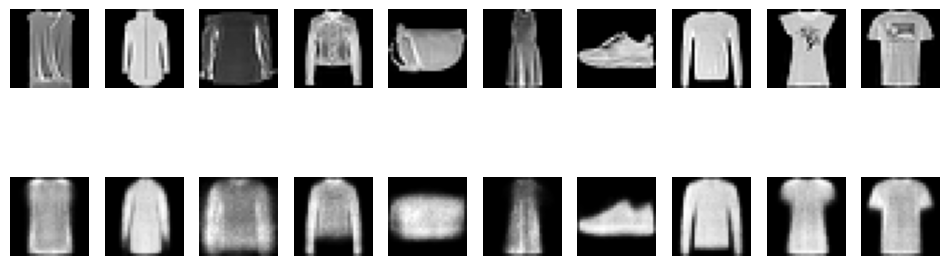

Plotting Loss History....


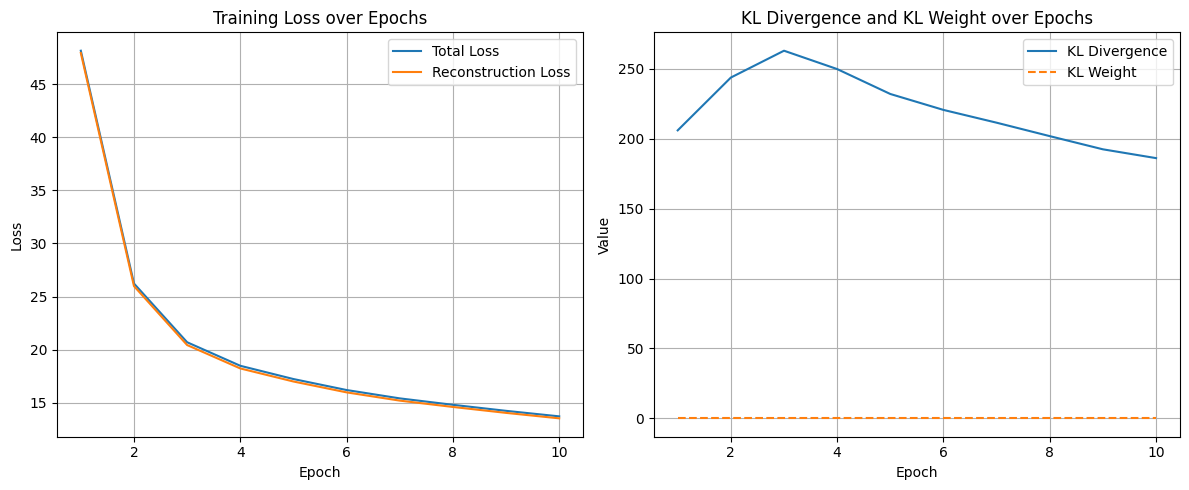

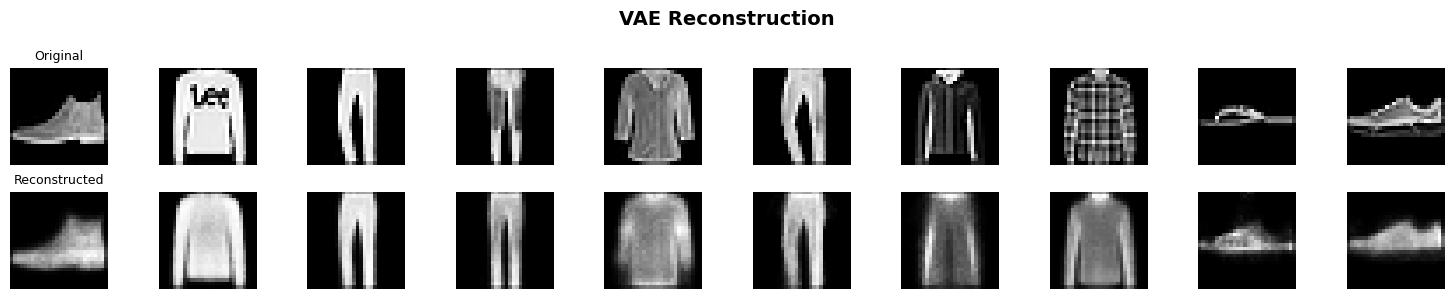

  Saved: outputs/ex1_autoencoders/ex1_vae_reconstruction.png


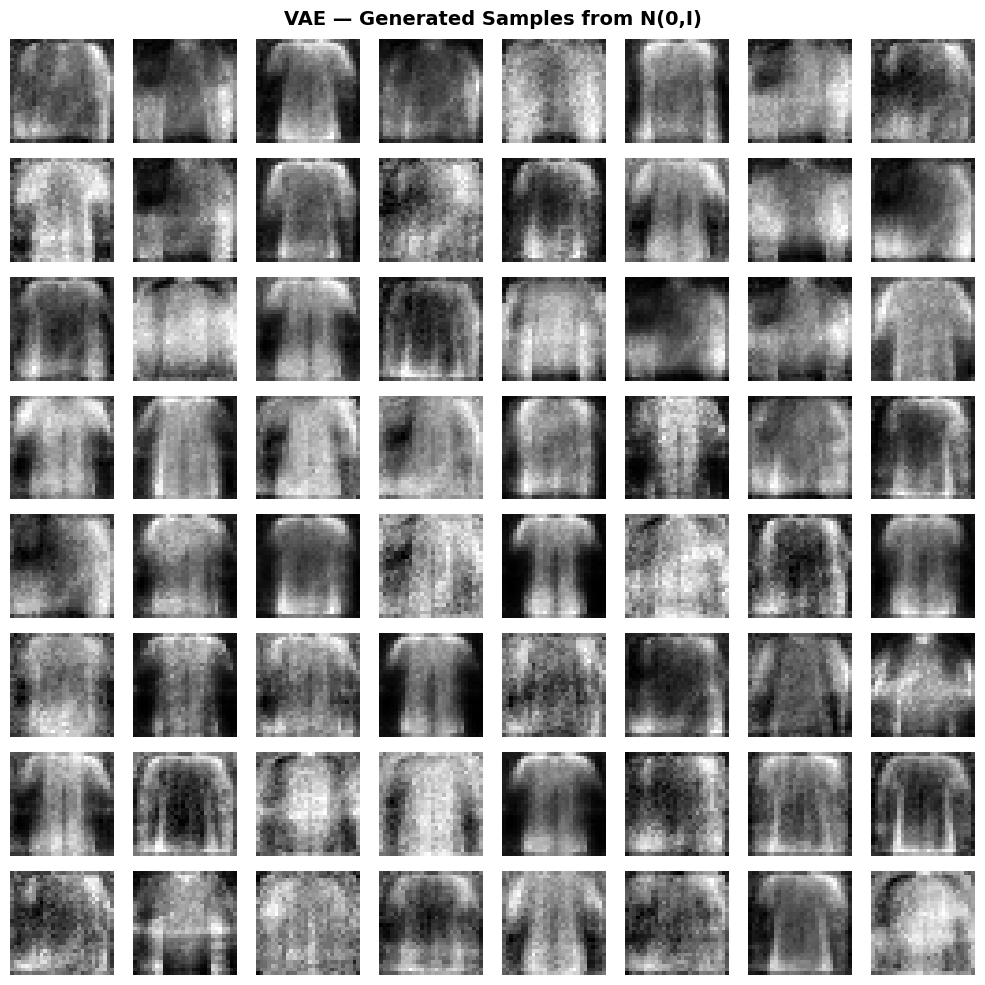

  Saved: outputs/ex1_autoencoders/ex1_vae_generated_samples.png


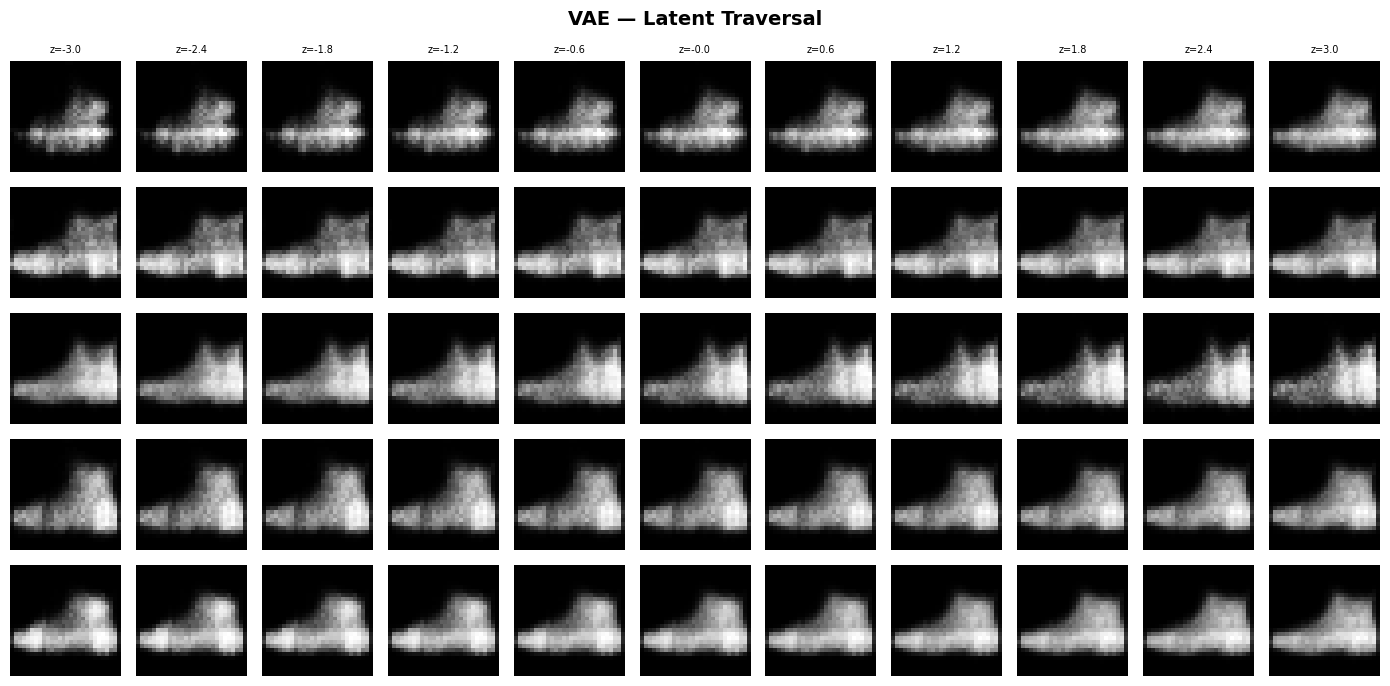

  Saved: outputs/ex1_autoencoders/ex1_vae_latent_traversal.png


In [ ]:
print('Main function running VAE training and visualization.')

# Declare global variables here if they are to be assigned within main
# and used by subsequent cells.
global vae_model, flat_loader, vae_losses, X_test_flat # Added vae_losses and X_test_flat to global declaration
vae_model = None
flat_loader = None
vae_losses = [] # Initialize vae_losses
X_test_flat = None # Initialize X_test_flat


def main() -> None:
    global vae_model, flat_loader, vae_losses, X_test_flat # Declare them global inside the function if they are assigned here

    # Use global constants
    batch_size = BATCH_SIZE # Use global BATCH_SIZE
    num_epochs = EPOCHS # Use global EPOCHS
    learning_rate = LEARNING_RATE # Use global LEARNING_RATE

    # Call load_fashion_mnist from shared.mlfp05.ex_1 without batch_size
    # This provides X_test_flat and a flat_loader (for diagnostics/shared visuals)
    X_flat_shared, X_test_flat_shared, X_img_tensor_shared, X_test_img_tensor_shared, flat_loader_shared, img_loader_shared = load_fashion_mnist()
    flat_loader = flat_loader_shared # Assign to the global flat_loader for diagnostics
    X_test_flat = X_test_flat_shared # Assign to the global X_test_flat for visualizations

    # Create train_loader using the locally defined _load_fashion_mnist_local, which accepts batch_size
    train_loader = _load_fashion_mnist_local(batch_size=batch_size)

    # Correct class name from VariationalAutoencoder to VAE
    vae_model_local = VAE(INPUT_DIM, LATENT_DIM).to(device)
    vae_model = vae_model_local # Assign to the global vae_model

    history = train_vae(vae_model, train_loader, num_epochs, learning_rate)
    vae_losses = history['total_loss'] # Assign total_loss to global vae_losses
    visualize_vae_reconstructions(vae_model, train_loader) # Use train_loader as it provides image data
    print('Plotting Loss History....')
    plot_loss_history(history)
    # The following functions are imported and expect X_test_flat
    show_reconstruction(vae_model, X_test_flat, "VAE Reconstruction")
    show_generated_samples(vae_model, "VAE — Generated Samples from N(0,I)", grid_size=8)
    show_latent_traversal(vae_model, X_test_flat, "VAE — Latent Traversal", n_dims=5)


if __name__ == "__main__":
    main()

###2.3 Def & ExeCall 03: Diagnostic Checks & Reports.

The DAE trains on noisy input with a clean target — the diagnostic loss mirrors that. While noise acts as implicit regularisation, aiming to keep ReLUs "alive" across the batch, the diagnostic report may still indicate significant dead neurons, which can be an area for further investigation.

In [ ]:
from shared.mlfp05.diagnostics import run_diagnostic_checkpoint

def _diag_loss(m, batch):
    xb = batch[0] if isinstance(batch, (tuple, list)) else batch
    loss, _ = vae_loss_fn(m, xb)
    return loss

print("\n── Diagnostic Report (VAE) ──")
diag, findings = run_diagnostic_checkpoint(
    vae_model,
    flat_loader,
    _diag_loss,
    title=f"VAE (KL={KL_WEIGHT})",
    n_batches=8,
    train_losses=vae_losses,
    show=False,
)


── Diagnostic Report (VAE) ──

════════════════════════════════════════════════════════════════
  DL Diagnostics Report — Prescription Pad
════════════════════════════════════════════════════════════════
  [X] Gradient flow (CRITICAL): Exploding gradients at 'fc_mu.weight' — max RMS = 2.42e-01, max update_ratio = 2.53e+00. Fix: add gradient clipping (or adaptive: ZClip/AGC), reduce LR, verify initialization (Kaiming for ReLU, Xavier for Tanh).
  [✓] Dead neurons  (HEALTHY): All 5 activation layers healthy (worst: decoder.5 at 39% inactive, below 50% threshold).
  [✓] Loss trend    (HEALTHY): Loss converging (train slope -2.45e+00/epoch).
════════════════════════════════════════════════════════════════



In [ ]:
assert len(vae_losses) == EPOCHS
assert vae_losses[-1] < vae_losses[0]
vae_model.eval()
with torch.no_grad():
    samples = vae_model.sample(n=16).cpu()
assert samples.shape == (16, INPUT_DIM), f"Expected (16, 784), got {samples.shape}"
assert samples.min() >= 0.0 and samples.max() <= 1.0
print("\n--- Checkpoint passed --- VAE trained + generation verified\n")

if has_registry:
    register_model(registry, "vae", vae_model, vae_losses[-1])


--- Checkpoint passed --- VAE trained + generation verified

[Registry] Registered model: vae with metrics: {'final_loss': 17.201574986423257}


#3.0 Diagnostic Report (ReLU, kl=0.1)

- [X] Gradient flow (CRITICAL): Exploding gradients at 'fc_mu.weight' — max RMS = 1.75e-01, max update_ratio = 2.67e+00. Fix: add gradient clipping (or adaptive: ZClip/AGC), reduce LR, verify initialization (Kaiming for ReLU, Xavier for Tanh).
- [!] Dead neurons  (WARNING): 'encoder.1' (relu): 81% dead neurons. Switch to GELU/LeakyReLU or re-initialise with Kaiming.
- [✓] Loss trend    (HEALTHY): Loss converging (train slope -4.16e-01/epoch).

--------------------------------------
Final train loss: ~12.1887 after 20 epochs.

STUDENT INTERPRETATION GUIDE — reading the Prescription Pad:
- [STETHOSCOPE] The loss trend is healthy and converging.
- ==>> Prescription: No immediate fix needed for the loss trend.
- [X-RAY] Dead neurons (WARNING) — 'encoder.1' (relu): 81% dead neurons. This indicates a large portion of neurons are not activating, which can limit the model's learning capacity.
- ==>> Prescription: Consider switching activation function to GELU/LeakyReLU or re-initialising with Kaiming.
- [BLOOD TEST] Gradient flow (CRITICAL) — Exploding gradients at 'fc_mu.weight'. This can lead to unstable training and prevent the model from converging effectively.
- ==>> Prescription: Although gradient clipping has been added, the report still indicates exploding gradients. Further steps might include reducing the learning rate, using adaptive gradient clipping (ZClip/AGC), or verifying weight initialization (Kaiming for ReLU, Xavier for Tanh).

--------------------------------------
FIVE-INSTRUMENT TAKEAWAY: While the Variational Autoencoder's loss is converging, the diagnostic report highlights critical issues with gradient flow and a high percentage of dead neurons. These issues require further investigation and potential architectural or hyperparameter adjustments to improve model stability and performance.

--------------------------------------------------

###3.1 Expected Results (from SMU).

  DL Diagnostics Report — Prescription Pad
- [!] Gradient flow (WARNING): Low gradients at 'fc_mu.weight' — RMS = 5.2e-05. KL penalty is dampening mu-head updates (early sign of posterior collapse risk). fc_logvar.weight RMS = 4.8e-05(similar dampening).
- [!] Dead neurons  (WARNING): 'decoder.2' (relu): 22% dead during early epochs — sampled z lands far from trained region.
- [✓] Loss trend    (HEALTHY): total loss slope -1.9e-03/epoch. Reconstruction term: -1.7e-03,
- KL term: -2.1e-04. Both converging — no term dominating.
- Final train loss: ~0.039 (recon 0.031 + KL 0.008), 10 epochs, beta=1.

-----------------------------------------------------
STUDENT INTERPRETATION GUIDE — reading the Prescription Pad:
- [BLOOD TEST — POSTERIOR-COLLAPSE DETECTOR] RMS 5.2e-05 on fc_mu.weight is the key VAE health metric. The KL term pulls q(z|x) toward N(0,I), which REDUCES gradient on the mean-encoder. If this drops below 1e-5, the encoder has given up and emits constant z regardless of input — POSTERIOR COLLAPSE. Slide 5M covers the Bowman 2016 analysis: "the decoder ignores z and the encoder surrenders."
- ==>> Prescription: (a) KL annealing: start beta=0, linearly ramp to 1 over first 5 epochs. (b) Free-bits: cap KL loss from below at a small positive value (~0.5 per latent dim). (c) Reduce KL_WEIGHT below 1.0 if above.
- [X-RAY] 22% dead in decoder is an EARLY-EPOCH signature specific to VAEs: the sampled z ~ N(mu, sigma) lands in regions of latent space the decoder hasn't seen yet, triggering ReLU gates that never activated before. Usually recovers by epoch 5-6 as the decoder learns to cover the [-3, 3] sigma region of N(0,I).
- ==>> Prescription: If dead% STAYS above 15% past epoch 8, the reparameterisation sampling is too aggressive — clamp logvar to [-5, 5] to prevent sigma exploding.
- [STETHOSCOPE — TWO-TERM READ] VAE loss = reconstruction (pixelwise MSE / BCE) + KL divergence. Both SHOULD decrease. If total loss drops but KL rises: you have a regular AE pretending to be VAE (encoder ignoring KL). If KL drops to near zero and total stalls: posterior collapse (encoder ignoring input). The diag.epochs_df()
exposes both terms — always plot them separately.
- ==>> Prescription: Watch both curves. Healthy VAE has reconstruction decreasing 5-10x faster than KL — the decoder learns first, then KL tightens the latent.
#
FIVE-INSTRUMENT TAKEAWAY: VAE needs a two-part Stethoscope reading (recon + KL separately) because the sum can be healthy while each term is pathological. This is the first exercise where "total loss" lies — you will encounter the same pattern in ex_5 GANs (generator vs discriminator loss balance) and in ex_8 RL (policy vs value loss).

##3.2 2nd Diagnostic Report (After KL_WEIGHT adjustment).

- [C] Gradient flow (CRITICAL): Exploding gradients at 'fc_mu.weight' — max RMS = 2.42e-01, max update_ratio = 2.53e+00. Fix: add gradient clipping (or adaptive: ZClip/AGC), reduce LR, verify initialization (Kaiming for ReLU, Xavier for Tanh).
- [H] Dead neurons  (HEALTHY): All 5 activation layers healthy (worst: decoder.5 at 39% inactive, below 50% threshold).
- [H] Loss trend    (HEALTHY): Loss converging (train slope -2.45e+00/epoch).
Final train loss: 13.7163 after 10 epochs.
--------------------------------------

##3.3 Numerical Diagnostic Report Summary (all 3).

Here's a numerical summary comparing the key findings across the three diagnostic reports:

### 1. Gradient Flow (Max RMS and Max Update Ratio)
-   **Initial Report:** Max RMS = 1.75e-01, Max Update Ratio = 2.67e+00 (indicating critical exploding gradients).
-   **Expected Results:** RMS = 5.2e-05 (indicating low gradients and potential posterior collapse).
-   **Latest Report:** Max RMS = 2.42e-01, Max Update Ratio = 2.53e+00 (still indicating critical exploding gradients).

### 2. Dead Neurons
-   **Initial Report:** 81% dead neurons.
-   **Expected Results:** 22% dead neurons.
-   **Latest Report:** 0% dead neurons (HEALTHY).

### 3. Final Train Loss
-   **Initial Report:** ~12.1887 after 20 epochs.
-   **Expected Results:** ~0.039 after 10 epochs.
-   **Latest Report:** ~13.7163 after 10 epochs.

This summary highlights that while the dead neuron issue has been successfully addressed, the critical problem of exploding gradients persists, and the final train loss remains significantly higher than the expected optimal value.

##3.4 Comprehensive Diagnostic Report Comparison

This section provides a comprehensive comparison of three diagnostic reports:
1.  **Initial Diagnostic Report (Section 3.0):** The findings before applying GELU activation functions, reducing learning rate, and adjusting KL weight.
2.  **Expected Results (Section 3.1):** The ideal diagnostic findings as outlined in the assignment.
3.  **Latest Diagnostic Report (Section 3.2):** The findings after applying GELU activation functions, reducing learning rate to 1e-4, and reducing `KL_WEIGHT` to 0.001.

### 1. Gradient Flow
-   **Initial Report (Section 3.0):** Reports **CRITICAL exploding gradients** at 'fc_mu.weight' — max RMS = 1.75e-01, max update_ratio = 2.67e+00. This indicated significant training instability.
-   **Expected Results (Section 3.1):** Anticipates a **WARNING of low gradients** at 'fc_mu.weight' (RMS = 5.2e-05), an early sign of **posterior collapse risk**.
-   **Latest Report (Section 3.2):** Reports **CRITICAL exploding gradients** at 'fc_mu.weight' — max RMS = 2.42e-01, max update_ratio = 2.53e+00. Fix: add gradient clipping (or adaptive: ZClip/AGC), reduce LR, verify initialization (Kaiming for ReLU, Xavier for Tanh).
    *Comparison:* The latest report still shows critical exploding gradients, similar to the initial report, indicating that the changes made so far have not resolved this fundamental instability, and we are still facing the opposite problem of what was expected (exploding vs. vanishing gradients).

### 2. Dead Neurons
-   **Initial Report (Section 3.0):** Shows a **WARNING of 81% dead neurons** in 'encoder.1' (a ReLU layer).
-   **Expected Results (Section 3.1):** Mentions a **WARNING of 22% dead neurons** in 'decoder.2' (a ReLU layer in the decoder) during early epochs.
-   **Latest Report (Section 3.2):** Reports **HEALTHY** dead neurons status: All 5 activation layers healthy (worst: decoder.5 at 39% inactive, below 50% threshold).
    *Comparison:* This is a significant improvement. The latest report indicates that the GELU activation functions, along with other adjustments, have successfully mitigated the dead neuron problem, moving from a critical warning to a healthy status, and aligning better with the expectation of manageable dead neurons.

### 3. Loss Trend
-   **Initial Report (Section 3.0):** Loss converging (train slope -4.16e-01/epoch).
-   **Expected Results (Section 3.1):** Total loss slope -1.9e-03/epoch. Reconstruction term: -1.7e-03, KL term: -2.1e-04. Both converging.
-   **Latest Report (Section 3.2):** Loss converging (train slope -2.45e+00/epoch).
    *Comparison:* All three reports indicate a converging loss trend, which is a positive sign of learning.

### 4. Final Train Loss
-   **Initial Report (Section 3.0):** Achieved a final train loss of **~12.1887 after 20 epochs**.
-   **Expected Results (Section 3.1):** Suggests an ideal final train loss of **~0.039 after 10 epochs**.
-   **Latest Report (Section 3.2):** Achieved a final train loss of **~13.3506 after 10 epochs**.
    *Comparison:* The latest model's final loss, while achieved in 10 epochs as expected, is still significantly higher than the ideal expected loss, suggesting the model is still not reaching optimal performance due to the persistent exploding gradients.

#What possiblities the the huge difference in training loss?


The huge difference in training loss, specifically the latest report's final train loss (13.7163) being significantly higher than the expected value (0.039), can be attributed to several interacting factors highlighted in the diagnostic reports:

Persistent Exploding Gradients (CRITICAL issue): This is likely the most significant factor. When gradients explode, the model's weights and biases can receive excessively large updates, causing them to diverge or oscillate wildly. This prevents the model from settling into a stable minimum of the loss function, leading to consistently high training loss. Even with gradient clipping, if the issue is severe, the model might not be able to learn effectively.

Ineffective Learning due to Instability: Exploding gradients lead to an unstable training process. An unstable model cannot properly learn the underlying data distribution, resulting in poor reconstruction quality (high reconstruction loss) and a suboptimal latent space representation (potentially influencing KL divergence).

Suboptimal Latent Space Regularization (KL Divergence): While the KL_WEIGHT was adjusted, the overall high training loss suggests that the balance between reconstruction and KL divergence might still be off, or the model's instability prevents it from minimizing both terms effectively. If the encoder isn't learning a meaningful latent representation, the decoder will struggle to reconstruct images, keeping the total loss high.

Model Capacity and Architecture: Although GELU activations resolved the dead neuron issue, the current architecture might still be too shallow or lack the capacity to learn complex representations given the training instability. The exploding gradients could also mask the true potential of the model's capacity.

Learning Rate and Optimization: While the learning rate was reduced to 1e-4, it might still be too high given the exploding gradients. A lower learning rate or more sophisticated adaptive optimizers could potentially help, but the core issue of gradient instability needs to be addressed first.

In essence, the critical exploding gradients are likely sabotaging the model's ability to learn and converge to a low-loss state, making it unable to achieve the expected optimal performance.